In [1]:
import numpy as np
import pandas as pd 
import os
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/datasets/abhi8923shriv/sentiment-analysis-dataset/training.1600000.processed.noemoticon.csv',header= 0,
                        encoding='ISO-8859-1')

df.head()

,polarity of tweet,id of the tweet,date of the tweet,query,user,text of the tweet
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048572 entries, 0 to 1048571
Data columns (total 6 columns):
 #   Column              Non-Null Count    Dtype 
---  ------              --------------    ----- 
 0   polarity of tweet   1048572 non-null  int64 
 1   id of the tweet     1048572 non-null  int64 
 2   date of the tweet   1048572 non-null  object
 3   query               1048572 non-null  object
 4   user                1048572 non-null  object
 5   text of the tweet   1048572 non-null  object
dtypes: int64(2), object(4)
memory usage: 48.0+ MB


In [4]:
for col in df.columns:
    print(repr(col))

'polarity of tweet\xa0'
'id of the tweet'
'date of the tweet'
'query'
'user'
'text of the tweet\xa0'


In [5]:
pd.Series({col:df[col].unique() for col in df})

polarity of tweet                                                [0, 4]
id of the tweet       [1467810672, 1467810917, 1467811184, 146781119...
date of the tweet     [Mon Apr 06 22:19:49 PDT 2009, Mon Apr 06 22:1...
query                                                        [NO_QUERY]
user                  [scotthamilton, mattycus, ElleCTF, Karoli, joy...
text of the tweet     [is upset that he can't update his Facebook by...
dtype: object

In [6]:
found = df[df["polarity of tweet\xa0"] == 2] 
found

,polarity of tweet,id of the tweet,date of the tweet,query,user,text of the tweet


In [7]:
df.rename(columns = {'polarity of tweet\xa0' : 'score', 'text of the tweet\xa0' : 'content'}, inplace=True)

In [8]:
df

,score,id of the tweet,date of the tweet,query,user,content
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
...,...,...,...,...,...,...
1048567,4,1960186342,Fri May 29 07:33:44 PDT 2009,NO_QUERY,Madelinedugganx,My GrandMa is making Dinenr with my Mum
1048568,4,1960186409,Fri May 29 07:33:43 PDT 2009,NO_QUERY,OffRoad_Dude,Mid-morning snack time... A bowl of cheese noo...
1048569,4,1960186429,Fri May 29 07:33:44 PDT 2009,NO_QUERY,Falchion,@ShaDeLa same here say it like from the Termi...
1048570,4,1960186445,Fri May 29 07:33:44 PDT 2009,NO_QUERY,jonasobsessedx,@DestinyHope92 im great thaanks wbuu?


In [9]:
df['score'] = df['score'].replace({4:1})
df

,score,id of the tweet,date of the tweet,query,user,content
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
...,...,...,...,...,...,...
1048567,1,1960186342,Fri May 29 07:33:44 PDT 2009,NO_QUERY,Madelinedugganx,My GrandMa is making Dinenr with my Mum
1048568,1,1960186409,Fri May 29 07:33:43 PDT 2009,NO_QUERY,OffRoad_Dude,Mid-morning snack time... A bowl of cheese noo...
1048569,1,1960186429,Fri May 29 07:33:44 PDT 2009,NO_QUERY,Falchion,@ShaDeLa same here say it like from the Termi...
1048570,1,1960186445,Fri May 29 07:33:44 PDT 2009,NO_QUERY,jonasobsessedx,@DestinyHope92 im great thaanks wbuu?


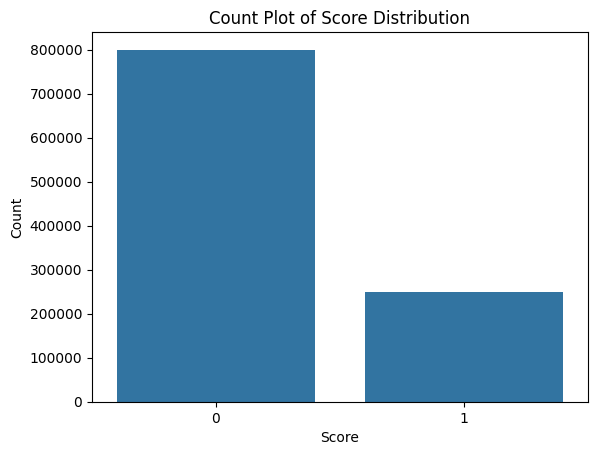

In [10]:
sns.countplot(x="score", data=df)
plt.title("Count Plot of Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

In [11]:
df.isna().sum().sum()

np.int64(0)

In [12]:
from sklearn.utils import resample

df_majority = df[df['score']==0]
df_minority = df[df['score']==1]
print(df_majority.shape, df_minority.shape)

(799996, 6) (248576, 6)


In [13]:
df_majority_downsampled = resample(df_majority, 
                                 replace=False,   
                                 n_samples=len(df_minority),    
                                 random_state=42) 


In [14]:
# df_resampled = pd.concat([df_majority_downsampled, df_minority]).reset_index().drop('index', inplace=True,axis = 1)
df_resampled = pd.concat([df_majority_downsampled, df_minority])
df_resampled.reset_index(inplace = True)
df_resampled.drop('index', inplace=True,axis = 1)
df_resampled.head()

,score,id of the tweet,date of the tweet,query,user,content
0,0,1974671959,Sat May 30 13:36:36 PDT 2009,NO_QUERY,jessicatamman,@amruth92 early bird! and you didnt reply to m...
1,0,2247756082,Fri Jun 19 19:34:35 PDT 2009,NO_QUERY,TinaF75,It is sooo hot tonight. I wish I had my pool u...
2,0,2286390032,Mon Jun 22 16:22:54 PDT 2009,NO_QUERY,hellomariely,@darkandrez No washing clothes
3,0,2061140384,Sat Jun 06 20:15:32 PDT 2009,NO_QUERY,Pochaccoyoly,@asexiness That sucks!
4,0,1880667573,Fri May 22 02:03:48 PDT 2009,NO_QUERY,Milseyworks,"until now, i haven't watch yet the finale of A..."


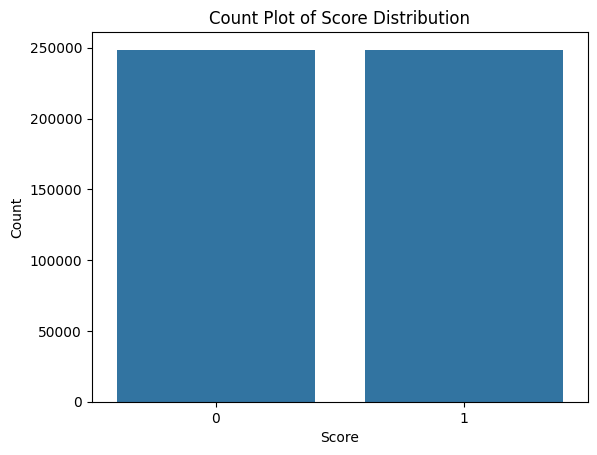

In [15]:
sns.countplot(x="score", data=df_resampled)
plt.title("Count Plot of Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

Data Preprocessing

In [16]:
from nltk.corpus import stopwords
from string import punctuation
import nltk
import re
from nltk.stem import WordNetLemmatizer

nltk.download('punkt_tab')      
nltk.download('wordnet')    
nltk.download('omw-1.4') 
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [17]:
stuff_to_be_removed = list(stopwords.words('english'))+list(punctuation)
corpus = df_resampled['content'].tolist()
print(len(corpus))
print(corpus[0])

497152
@amruth92 early bird! and you didnt reply to my facebook wall post  xo


In [18]:
final_corpus = []
final_corpus_joined = []
for i in df_resampled.index:

    text = re.sub('[^a-zA-Z]', ' ', df_resampled['content'][i])
    #Convert to lowercase
    text = text.lower()
    #remove tags
    text=re.sub("&lt;/?.*?&gt;"," &lt;&gt; ",text)
    
    # remove special characters and digits
    text=re.sub("(\\d|\\W)+"," ",text)
    
    ##Convert to list from string
    text = text.split()

    #Lemmatisation
    lem = WordNetLemmatizer()
    text = [lem.lemmatize(word) for word in text 
            if not word in stuff_to_be_removed] 
    text1 = " ".join(text)
    final_corpus.append(text)
    final_corpus_joined.append(text1)


In [19]:
data_cleaned = pd.DataFrame()
data_cleaned["text"] = final_corpus_joined
data_cleaned["score"] = df_resampled["score"].values
data_cleaned.head()

,text,score
0,amruth early bird didnt reply facebook wall po...,0
1,sooo hot tonight wish pool outside skinny dipp...,0
2,darkandrez washing clothes,0
3,asexiness suck,0
4,watch yet finale ai waiting replay always miss...,0


In [20]:
data_eda = data_cleaned.copy()
data_eda.head()

,text,score
0,amruth early bird didnt reply facebook wall po...,0
1,sooo hot tonight wish pool outside skinny dipp...,0
2,darkandrez washing clothes,0
3,asexiness suck,0
4,watch yet finale ai waiting replay always miss...,0


In [21]:
positive = data_eda[data_eda['score'] == 1]
positive_list = positive['text'].tolist()

negative = data_eda[data_eda['score'] == 0]
negative_list = negative['text'].tolist()


In [22]:
positive_all = " ".join(positive['text'])
negative_all = " ".join(negative['text'])

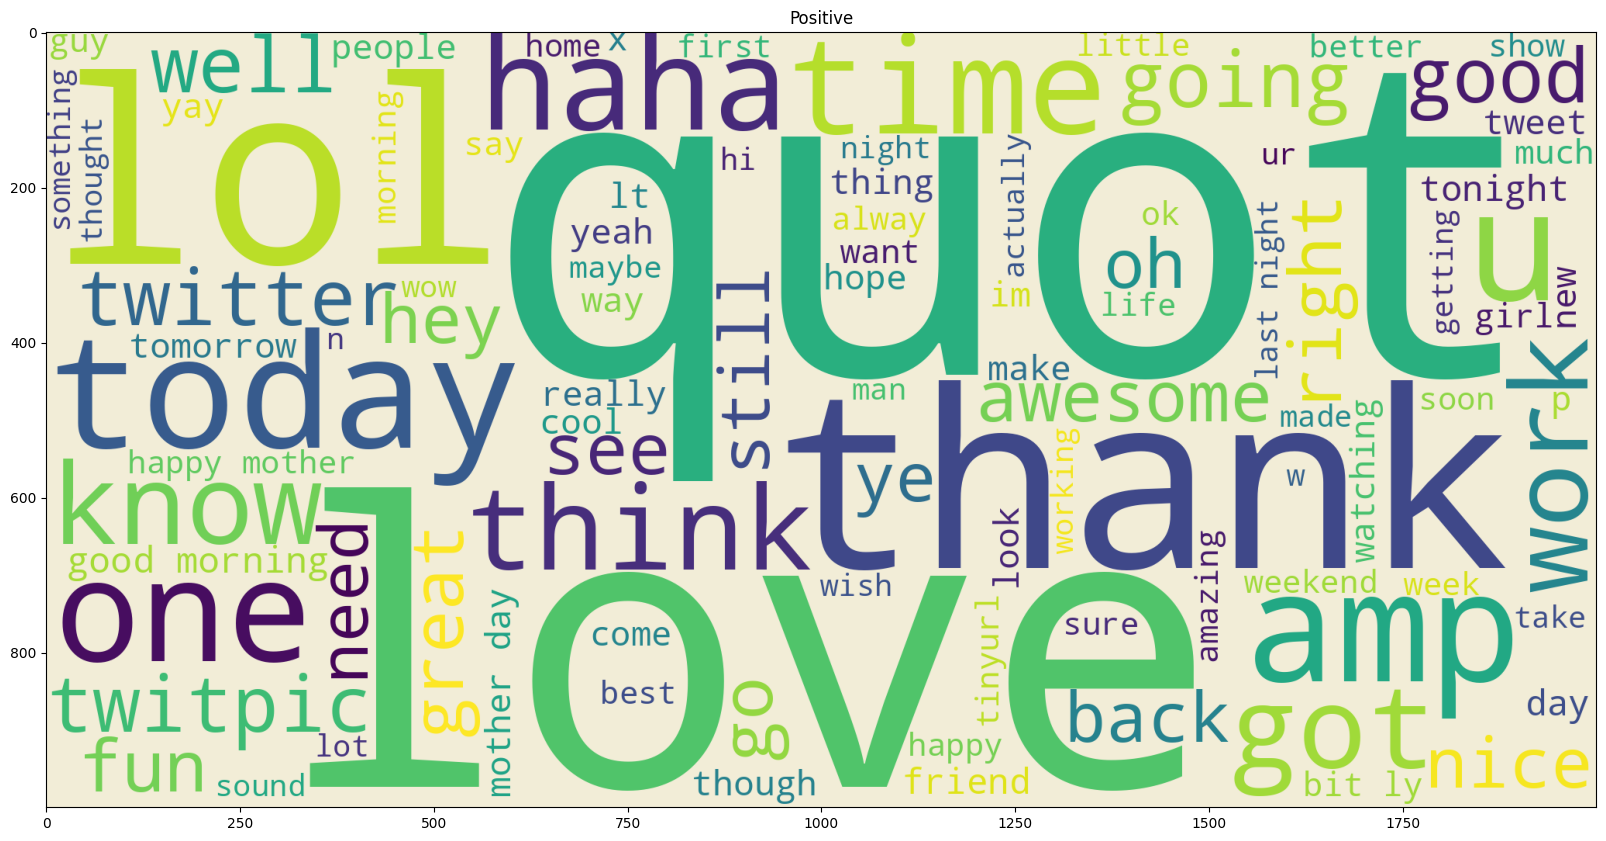

In [23]:
from wordcloud import WordCloud
WordCloud()
wordcloud = WordCloud(width=2000,
                      height=1000,
                      background_color='#F2EDD7FF',
                      max_words = 100).generate(positive_all)

plt.figure(figsize=(20,30))
plt.imshow(wordcloud)
plt.title("Positive")
plt.show()

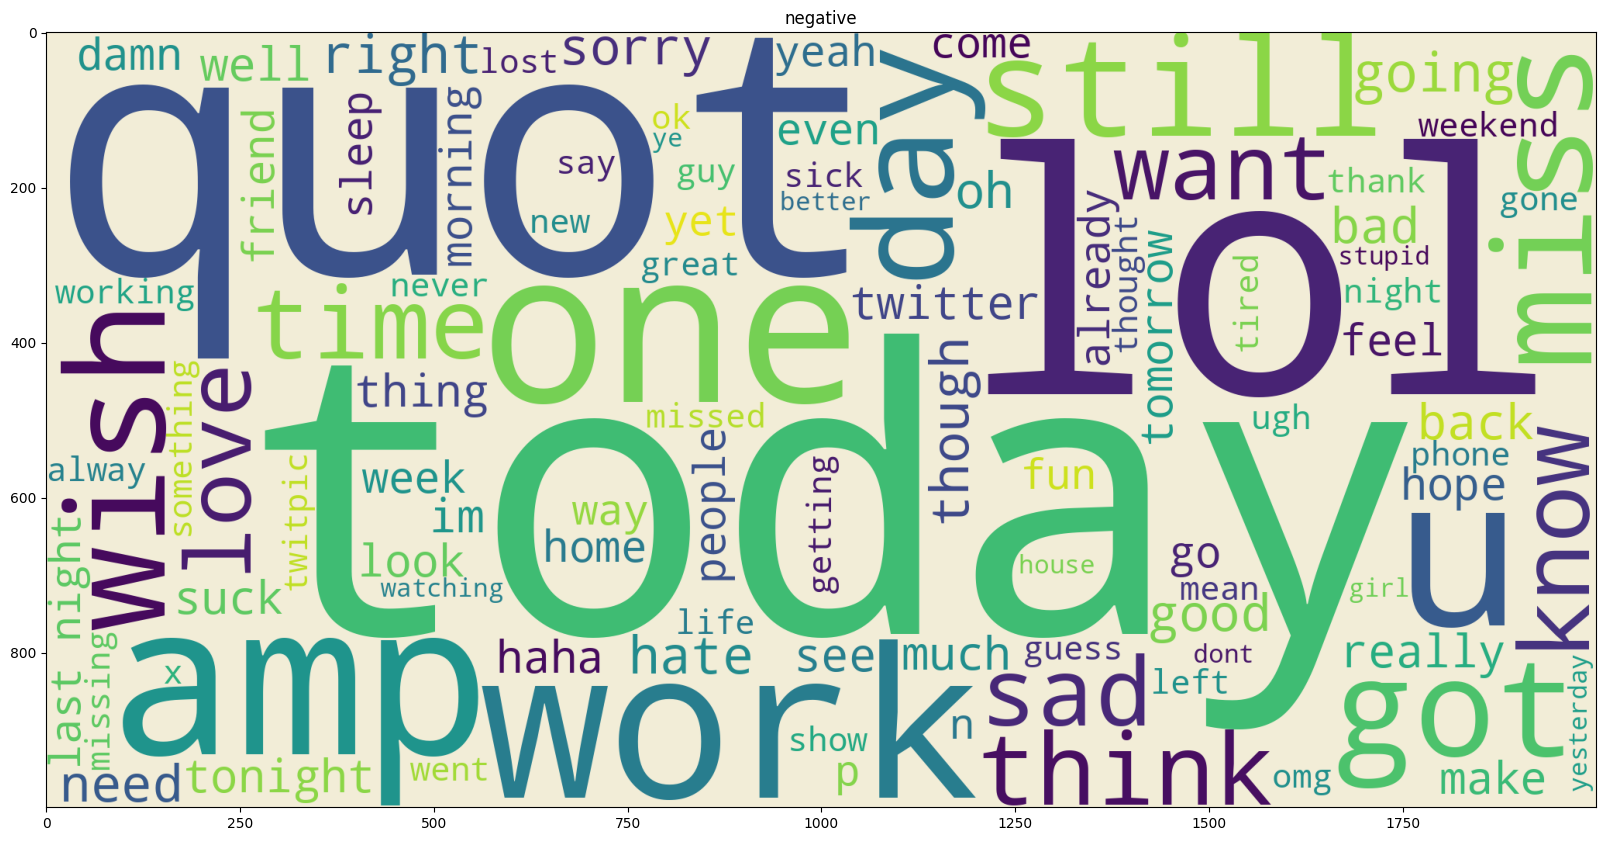

In [24]:
WordCloud()
wordcloud = WordCloud(width=2000,
                      height=1000,
                      background_color='#F2EDD7FF',
                      max_words = 100).generate(negative_all)

plt.figure(figsize=(20,30))
plt.imshow(wordcloud)
plt.title("negative")
plt.show()

Model

In [25]:
def get_tweets_for_model(cleaned_strings_list):
    for tweet in cleaned_strings_list:
        yield dict([token, True] for token in tweet.split()) 
        
positive_tokens_for_model = get_tweets_for_model(positive_list)
negative_tokens_for_model = get_tweets_for_model(negative_list)


In [26]:
import random

positive_dataset = [(review_dict, "Positive")
                     for review_dict in positive_tokens_for_model]

negative_dataset = [(review_dict, "Negative")
                     for review_dict in negative_tokens_for_model]
dataset = positive_dataset + negative_dataset



In [27]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

In [28]:
from nltk import classify
from nltk import NaiveBayesClassifier
classifier = NaiveBayesClassifier.train(train_data)

print(" Training Accuracy is:", round(classify.accuracy(classifier, train_data),2)*100)

print("Testing Accuracy is:", round(classify.accuracy(classifier, test_data),2)*100)

print(classifier.show_most_informative_features(10))


 Training Accuracy is: 86.0
Testing Accuracy is: 77.0
Most Informative Features
                    iran = True           Negati : Positi =    115.1 : 1.0
                 fawcett = True           Negati : Positi =     61.0 : 1.0
             squarespace = True           Negati : Positi =     46.7 : 1.0
                  booooo = True           Negati : Positi =     43.0 : 1.0
                  farrah = True           Negati : Positi =     36.7 : 1.0
                  asthma = True           Negati : Positi =     31.7 : 1.0
                  youngq = True           Negati : Positi =     29.0 : 1.0
         michaelgrainger = True           Positi : Negati =     29.0 : 1.0
               upsetting = True           Negati : Positi =     28.3 : 1.0
                   alike = True           Positi : Negati =     28.3 : 1.0
None


TF-IDF

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    data_cleaned['text'], 
    data_cleaned['score'], 
    test_size=0.2, 
    random_state=42
)

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

In [31]:
# tfidf_vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 4))

# X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# X_test_tfidf = tfidf_vectorizer.transform(X_test)

vectorizer = CountVectorizer(binary=True, ngram_range=(1, 1), max_features=None)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [32]:
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

train_predictions = nb_classifier.predict(X_train_tfidf)
test_predictions = nb_classifier.predict(X_test_tfidf)

print("Training Accuracy:", round(accuracy_score(y_train, train_predictions) * 100, 2), "%")
print("Testing Accuracy:", round(accuracy_score(y_test, test_predictions) * 100, 2), "%")

Training Accuracy: 84.15 %
Testing Accuracy: 76.88 %
